# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [2]:
df = pd.read_csv('data/RFM_base.csv')
df.set_index('customer_unique_id', inplace=True)

df

,recency,frequency,monetary,max_order_date
customer_unique_id,,,,
7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,2017-10-02
af07308b275d755c9edb36a90c618231,85,1,118.70,2018-07-24
3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,2018-08-08
7c142cf63193a1473d2e66489a9ae977,333,1,45.00,2017-11-18
72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,2018-02-13
...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00,2017-03-09
da62f9e57a76d978d02ab5362c509660,253,1,174.90,2018-02-06
737520a9aad80b3fbbdad19b66b37b30,416,1,205.99,2017-08-27


In [3]:
offset = -1
n_periods_max = 24
n_periods_min = 8

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods_max, n_periods_min, offset))
list_offsets

[24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9]

In [4]:
min_date = pd.to_datetime(df['max_order_date'].min())
max_date = pd.to_datetime(df['max_order_date'].max())

print(min_date.strftime('%Y-%m-%d'))
print(max_date.strftime('%Y-%m-%d'))

2016-09-04
2018-10-16


In [5]:
n_period_sp = 5
limit_date = (max_date - pd.DateOffset(weeks=list_offsets[n_period_sp])).strftime('%Y-%m-%d')

print (f"Date max {max_date.strftime('%Y-%m-%d')} après retrait de {n_period_sp} semaines : {limit_date}")

Date max 2018-10-16 après retrait de 5 semaines : 2018-06-05


In [6]:
dfs = {}

#list_n_df
#len_offsets = len(list_offsets)
#offsets_count = list(range(1, len_offsets, 1))
n = 1

for i in list_offsets:
    subset = df[df['max_order_date'] <= (max_date - pd.DateOffset(weeks=i)).strftime('%Y-%m-%d')]
    #dfs[f'df_{i}'] = subset
    dfs[f'df_{n}'] = subset
    n+=1

print(dfs.keys())

dict_keys(['df_1', 'df_2', 'df_3', 'df_4', 'df_5', 'df_6', 'df_7', 'df_8', 'df_9', 'df_10', 'df_11', 'df_12', 'df_13', 'df_14', 'df_15', 'df_16'])


In [7]:
for name, df in dfs.items():
    print(f'{name}: shape {df.shape}, max date {df.max_order_date.max()}')

df_1: shape (70279, 4), max date 2018-05-01
df_2: shape (72213, 4), max date 2018-05-08
df_3: shape (74169, 4), max date 2018-05-15
df_4: shape (75661, 4), max date 2018-05-22
df_5: shape (76489, 4), max date 2018-05-29
df_6: shape (77672, 4), max date 2018-06-05
df_7: shape (79210, 4), max date 2018-06-12
df_8: shape (80644, 4), max date 2018-06-19
df_9: shape (82089, 4), max date 2018-06-26
df_10: shape (83398, 4), max date 2018-07-03
df_11: shape (84448, 4), max date 2018-07-10
df_12: shape (85605, 4), max date 2018-07-17
df_13: shape (87348, 4), max date 2018-07-24
df_14: shape (88992, 4), max date 2018-07-31
df_15: shape (91157, 4), max date 2018-08-07
df_16: shape (92980, 4), max date 2018-08-14


In [8]:
# drop max_order_date column
for name, df in dfs.items():
    df = df.drop('max_order_date', axis=1)
    dfs[name] = df

for name, df in dfs.items():
    print(f'{name}: {df.shape}')
    #print()

df_1: (70279, 3)
df_2: (72213, 3)
df_3: (74169, 3)
df_4: (75661, 3)
df_5: (76489, 3)
df_6: (77672, 3)
df_7: (79210, 3)
df_8: (80644, 3)
df_9: (82089, 3)
df_10: (83398, 3)
df_11: (84448, 3)
df_12: (85605, 3)
df_13: (87348, 3)
df_14: (88992, 3)
df_15: (91157, 3)
df_16: (92980, 3)


In [9]:
dfs['df_1']

,recency,frequency,monetary
customer_unique_id,,,
7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
7c142cf63193a1473d2e66489a9ae977,333,1,45.00
72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90
80bb27c7c16e8f973207a5086ab329e2,465,1,147.90
36edbb3fb164b1f16485364b6fb04c73,554,1,49.90
...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00
da62f9e57a76d978d02ab5362c509660,253,1,174.90
737520a9aad80b3fbbdad19b66b37b30,416,1,205.99


# train kmeans datasets


In [10]:
skewness = dfs['df_1'].select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['frequency', 'monetary']
['recency']


In [11]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [12]:
# drop max_order_date column
X_stds = {}

for name, df in dfs.items():
    df = customTransform(df, cols_skewed, cols_unskewed)
    name_split = name.split("_")
    X_stds[f'X_{name_split[1]}'] = df

In [13]:
X_stds.keys()

dict_keys(['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8', 'X_9', 'X_10', 'X_11', 'X_12', 'X_13', 'X_14', 'X_15', 'X_16'])

In [14]:
for name, df in X_stds.items():
    print(f'{name}: {df.shape}')
    #print()

X_1: (70279, 3)
X_2: (72213, 3)
X_3: (74169, 3)
X_4: (75661, 3)
X_5: (76489, 3)
X_6: (77672, 3)
X_7: (79210, 3)
X_8: (80644, 3)
X_9: (82089, 3)
X_10: (83398, 3)
X_11: (84448, 3)
X_12: (85605, 3)
X_13: (87348, 3)
X_14: (88992, 3)
X_15: (91157, 3)
X_16: (92980, 3)


In [15]:
X_stds['X_1']

,recency,frequency,monetary
0,1.110223e-16,-0.275808,0.227718
1,-3.469447e-18,-0.693065,-0.143910
2,-3.469447e-18,-1.640992,-0.831817
3,-3.469447e-18,0.593994,0.899811
4,-3.469447e-18,-0.576461,1.603531
...,...,...,...
70274,-3.469447e-18,-0.169987,1.864461
70275,-3.469447e-18,0.765315,-0.776468
70276,-3.469447e-18,0.930065,0.512369
70277,-3.469447e-18,1.474337,-0.547165


## Check training first dataset

BatchKmeans 2 clusters, sil score : 0.37154033829389316
BatchKmeans 3 clusters, sil score : 0.3757516925584039
BatchKmeans 4 clusters, sil score : 0.35802484347731905
BatchKmeans 5 clusters, sil score : 0.3319125897722945
BatchKmeans 6 clusters, sil score : 0.33794496257196605
BatchKmeans 7 clusters, sil score : 0.3239163073943694
BatchKmeans 8 clusters, sil score : 0.3035962118227052
BatchKmeans 9 clusters, sil score : 0.3211093563651523
BatchKmeans 10 clusters, sil score : 0.3298934777485435
BatchKmeans 11 clusters, sil score : 0.325994974291839
BatchKmeans 12 clusters, sil score : 0.3194044201227129
BatchKmeans 13 clusters, sil score : 0.3315300572959748
BatchKmeans 14 clusters, sil score : 0.31141455755851455
BatchKmeans 15 clusters, sil score : 0.32412766873763627


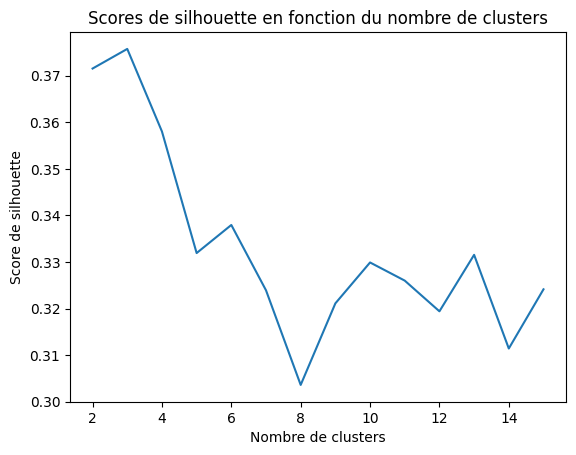

Le nombre optimal de clusters est : 3


In [16]:
X_std = X_stds['X_1'].copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

In [17]:
sorted_scores = np.argsort(scores)[::-1]
top_indices = sorted_scores[:5]

print("Les 5 plus grands score de silhouette sont :")

for indice in top_indices:
    print(f"{indice+2} clusters pour {scores[indice]} score de silhouette")

Les 5 plus grands score de silhouette sont :
3 clusters pour 0.3757516925584039 score de silhouette
2 clusters pour 0.37154033829389316 score de silhouette
4 clusters pour 0.35802484347731905 score de silhouette
6 clusters pour 0.33794496257196605 score de silhouette
5 clusters pour 0.3319125897722945 score de silhouette


In [18]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 500482.2674248391.
Iteration 1, inertia 140558.00000000023.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 117539.7692520293.
Iteration 1, inertia 96937.06774255043.
Iteration 2, inertia 91832.94390427253.
Iteration 3, inertia 89979.17696790316.
Iteration 4, inertia 89388.20003312471.
Iteration 5, inertia 89209.44108190537.
Iteration 6, inertia 89160.46307119823.
Iteration 7, inertia 89144.09911729384.
Iteration 8, inertia 89138.64631593475.
Converged at iteration 8: center shift 3.210069676623906e-05 within tolerance 6.6666666666669e-05.
3
Initialization complete
Iteration 0, inertia 74463.45232137255.
Iteration 1, inertia 64648.00743996408.
Iteration 2, inertia 62083.909236027845.
Iteration 3, inertia 60904.90731968598.
Iteration 4, inertia 60068.23067997137.
Iteration 5, inertia 59371.237235165085.
Iteration 6, inertia 58777.99345965092.
Iteration 7, inertia 58308.10618614995.
Iteration 8, i

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

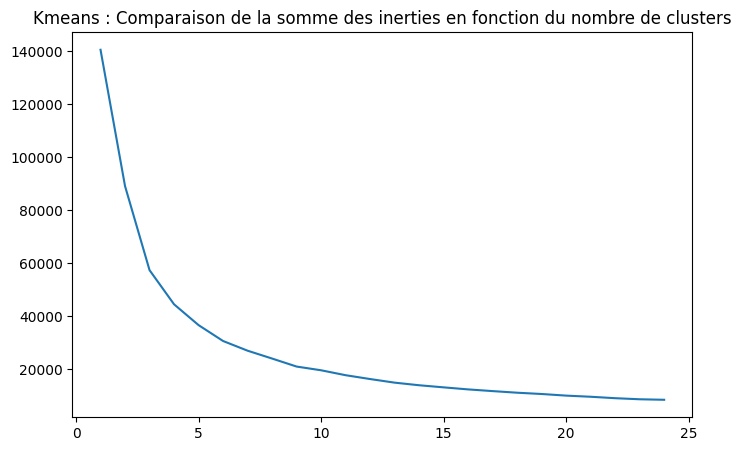

In [19]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(x=list(inertia.keys()),
             y=list(inertia.values())
            )

### Train and compare through time

In [20]:
clusters_num = 4

dict_Kmeans_X = {}

for name, df in X_stds.items():
    kmeans = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(df)
    dict_Kmeans_X[f'kmeans_{name}'] = kmeans

Initialization complete
Iteration 0, inertia 64472.97923892856.
Iteration 1, inertia 53575.89473153482.
Iteration 2, inertia 49978.31571916756.
Iteration 3, inertia 48660.21609363727.
Iteration 4, inertia 48126.499833489914.
Iteration 5, inertia 47862.66265573134.
Iteration 6, inertia 47728.20128867278.
Iteration 7, inertia 47661.04819559606.
Iteration 8, inertia 47617.23020402856.
Iteration 9, inertia 47586.95748658453.
Iteration 10, inertia 47566.647814549644.
Iteration 11, inertia 47551.02706737172.
Iteration 12, inertia 47541.059642197724.
Iteration 13, inertia 47532.37014424513.
Iteration 14, inertia 47521.88984977748.
Iteration 15, inertia 47509.878683608775.
Iteration 16, inertia 47494.18646889697.
Iteration 17, inertia 47476.38142784545.
Iteration 18, inertia 47457.893313650566.
Iteration 19, inertia 47438.19678292412.
Iteration 20, inertia 47419.026390165905.
Iteration 21, inertia 47400.53743956674.
Iteration 22, inertia 47382.78286328402.
Iteration 23, inertia 47366.322040740

# Compute ARI

In [21]:
scores = []
first_kmeans = dict_Kmeans_X['kmeans_X_1']

for name, kmeans in dict_Kmeans_X.items():
    X_name = name.replace("kmeans_", "")
    ari = adjusted_rand_score(kmeans.labels_, first_kmeans.predict(X_stds[X_name]))
    scores.append(ari)

#periodes = 

In [22]:
scores

[1.0,
 0.9958452196082822,
 0.9951509994080369,
 0.9922031832673561,
 0.9928760734763447,
 0.9871113944672616,
 0.9882626213061178,
 0.9832567126106482,
 0.9819350136385144,
 0.9807674590345098,
 0.9814141286717581,
 0.9813802072218497,
 0.7709838030813202,
 0.769903698804659,
 0.7753318233700779,
 0.784495893728366]

In [23]:
scores_len = len(scores)
periodes = list(range(0, scores_len, 1))

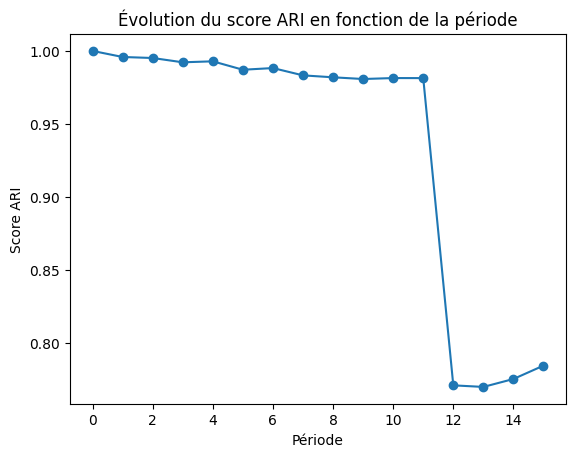

In [24]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()

In [25]:
scores[0:13]

[1.0,
 0.9958452196082822,
 0.9951509994080369,
 0.9922031832673561,
 0.9928760734763447,
 0.9871113944672616,
 0.9882626213061178,
 0.9832567126106482,
 0.9819350136385144,
 0.9807674590345098,
 0.9814141286717581,
 0.9813802072218497,
 0.7709838030813202]

In [26]:
scores[12] - scores[11]

-0.2103964041405295